<a href="https://colab.research.google.com/github/annagiacometti/mooc-sna-evolution/blob/main/ENG_Giacometti_Analisi_SNA_MOOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Analysis Code: The Non-Significant Impact of Profile Attributes on Social Network Centrality in a MOOC Context: A Comparative Study**

**Author:** Anna Giacometti

**Degree Program:** Master's Degree in Digital Humanities for the Cultural Industry

**University:** University of Palermo

**Reference Paper:** *The Non-Significant Impact of Profile Attributes on Social Network Centrality in a MOOC Context: A Comparative Study*

# Introduction: Research Question and Objectives

## Context and Motivation

The project analyzes the social dynamics and interactions within two consecutive editions of the MOOC-Ed (Massive Open Online Course for educators) **Digital Learning and Teaching**, which are labeled DLT1 and DLT2.

Objective: The goal is to investigate the impact of pre-existing factors (user profile) and course design modifications (evolution from DLT1 to DLT2) on user performance and centrality within the interaction network.

Social Network Analysis (SNA) is used to measure centrality, and OLS Regression is applied to test the association between profile variables and centrality.

## Research Question

The central question guiding the analysis is:

**Given the evolution of the MOOC-Ed DLT course design between DLT1 and DLT2, to what extent do the participants' profile characteristics (Professional Role, Experience, and Gender) associate with their network dynamics (Participation and Centrality), and how does this association differ between the two editions of the MOOC-Ed?**

## Project Objectives

To answer the RQ, the project is structured around the following key objectives, which correspond to the subsequent phases of the Notebook:

1. Centrality Measurement (Phase 3): Calculate fundamental centrality indices (In-Degree, Out-Degree, Betweenness) to quantify the Prominence, Participation, and Brokerage of each participant.

2. Inferential Analysis (Phase 4): Use OLS Regression to test the statistical association between profile variables (including interactions: $\text{Gender} \times \text{Edition}$) and the three centrality indices.

3. Comparative Visualization (Phase 5): Graphically explore and represent the distribution of centrality based on profile factors and the comparison between the DLT1 and DLT2 editions.

4. Structural Implications (Phase 6): Determine if and how the evolution of the course design modified the internal structural relationships of the network (e.g., correlation between In-Degree and Betweenness).

# PHASE I: Setup and Library Loading

This phase initializes the workspace, imports all necessary libraries for the analysis, and defines the standard settings for plot quality and saving.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Standard plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

# Initialize counter for saving figures
FIG_COUNTER = 1

def save_fig(title):
    """
    Function to save the current plot with a sequential file name and high resolution.
    """
    global FIG_COUNTER
    plt.savefig(f"Figure_{FIG_COUNTER}_{title}.png", dpi=300, bbox_inches="tight")
    print(f"Figure {FIG_COUNTER} saved as Figure_{FIG_COUNTER}_{title}.png")
    FIG_COUNTER += 1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# PHASE II: Data Preparation, Cleaning, and Alignment

## 2.1: Dataset Loading

The four essential datasets are loaded from Google Drive, distinguishing between Edgelist (interaction edges) and Nodelist (participant attributes) for the DLT1 and DLT2 editions.

In [8]:
# DLT1
df_archi_dlt1 = pd.read_csv(
    "https://drive.google.com/uc?id=1cJipZwM6Z4geeGz2pGFLuuimnMOLw6rM"
)

df_nodi_dlt1 = pd.read_csv(
    "https://drive.google.com/uc?id=1abimSmXSfe079US0ZDhiiApdMbD2sGiM"
)

# DLT2
df_archi_dlt2 = pd.read_csv(
    "https://drive.google.com/uc?id=1weMW45PcMAFm5syNh1Oq03FpRS6pFE4x"
)

df_nodi_dlt2 = pd.read_csv(
    "https://drive.google.com/uc?id=1nOOivG-fH28les7-EBlRL4ZVKpMVEAyq"
)

## 2.2: EDA, Dataset Exploration

Preliminary examination of the datasets to understand their structure, data types, identify any missing values, and verify consistency between the interaction data (Edges) and the profile data (Nodes).

### A. DLT1 Nodes Overview

In [9]:
# --- EDA: DLT1 Nodes Overview ---
print("\n--- EDA: DLT1 Nodes Overview ---")

# DataFrame Dimensions: (Number of Participants, Number of Profile Variables)
print("Dimensions:", df_nodi_dlt1.shape)

# Display the first 5 rows
print(df_nodi_dlt1.head())

# Concise summary and data types
print("\nInfo and Data Types:")
print(df_nodi_dlt1.info(verbose=False))

# Distribution of the 'gender' variable, including missing values (NA)
print("\nDLT1 Gender Distribution:")
print(df_nodi_dlt1['gender'].value_counts(dropna=False))

# Distribution of the 'role1' variable (top 5 most frequent categories)
print("\nDLT1 Role Distribution (Top 5):")
print(df_nodi_dlt1['role1'].value_counts().head())

# Check and count Null values (NaN) for each column
print("\nNull Values Check (DLT1 Nodes, per column):")
print(df_nodi_dlt1.isnull().sum())

# Overall total of Null values in the DLT1 Nodes DataFrame
print("\nTotal Null Values in DLT1 Nodes DataFrame:")
print(df_nodi_dlt1.isnull().sum().sum())

# Duplicates Check (identification of potential duplicate participants)
print("\nDuplicates Check (DLT1 Nodes - All Columns):")
print(df_nodi_dlt1.duplicated().sum())


--- EDA: DLT1 Nodes Overview ---
Dimensions: (445, 13)
   UID  Facilitator          role1  experience experience2      grades  \
0    1            0       libmedia           1     6 to 10   secondary   
1    2            0  classteaching           1     6 to 10   secondary   
2    3            0  districtadmin           2    11 to 20  generalist   
3    4            0  classteaching           2    11 to 20      middle   
4    5            0    otheredprof           3         20+  generalist   

  location     region country group  gender  expert  connect  
0       VA      South      US    UZ  female     0.0      1.0  
1       FL      South      US    DL  female     0.0      0.0  
2       PA  Northeast      US    OT  female     0.0      1.0  
3       NC      South      US     N  female     0.0      0.0  
4       AL      South      US    AC  female     0.0      0.0  

Info and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Columns: 13 entries, UID to

#### EDA Output Interpretation - DLT1 Nodes

The initial exploratory data analysis of the DLT1 nodes has led to the following crucial observations, which will guide the subsequent cleaning and alignment phases:

##### 1. Structure and Alignment
* **Dimensions:** The dataset includes 445 participants (nodes) described by 13 profile variables.
* **Name Inconsistency (Action Required):** The names of the key profile columns (role1, experienxe, experience2) differ from the standard names in the DLT2 dataset. This confirms the need for renaming (alignment) in the next phase.

##### 2. Profile Distribution
* **Gender Distribution:** There is only one missing value. The network is **strongly gender-imbalanced** (approximately 2:1 in favor of women), a key social factor to consider in the SNA analysis.
* **Role Distribution:** The most common roles are **Instructional Technologists** and **Classroom Teachers**, confirming that the MOOC is attended by various K-12 professionals.

##### 3. Data Quality
* **Missing (Null) Values:** The *isnull().sum().sum()* analysis confirmed that missing values are very sparse (only 11 in total across 445 nodes) and do not pose a threat to data integrity. Removing these incomplete rows will be the preferred approach.

### B. DLT2 Nodes Overview

In [10]:
# --- EDA: DLT2 Nodes Overview ---
print("\n--- EDA: DLT2 Nodes Overview ---")

# DataFrame Dimensions (DLT2)
print("Dimensions:", df_nodi_dlt2.shape)

# Display the first 5 rows
print(df_nodi_dlt2.head())

# Concise summary and data types
print("\nInformation and Data Types:")
print(df_nodi_dlt2.info(verbose=False))

# Distribution of the 'gender' variable, including missing values (NA)
print("\nDLT2 Gender Distribution:")
print(df_nodi_dlt2['gender'].value_counts(dropna=False))

# Distribution of the 'role' variable (top 5 most frequent categories)
print("\nDLT2 Role Distribution (Top 5):")
print(df_nodi_dlt2['role'].value_counts().head())

# Check and count Null values (NaN) per column
print("\nNull Values Check (DLT2 Nodes, per column):")
print(df_nodi_dlt2.isnull().sum())

# Grand total of Null values in the DLT2 Nodes DataFrame
print("\nTotal Null Values in DLT2 Nodes DataFrame:")
print(df_nodi_dlt2.isnull().sum().sum())

# Check for Duplicates (identifying potential duplicate participants)
print("\nDuplicates Check (DLT2 Nodes - All Columns):")
print(df_nodi_dlt2.duplicated().sum())


--- EDA: DLT2 Nodes Overview ---
Dimensions: (492, 13)
   uid  facilitator               role  experience2  experience      grades  \
0    1            0         curriculum            2          17  generalist   
1    2            0              other            1           3     primary   
2    3            0  instructionaltech            2          20  generalist   
3    4            0  instructionaltech            2          12      middle   
4    5            0              other            1           0  generalist   

  location         region country group  gender  expert  connect  
0       IN        Midwest      US    AL    male       0        0  
1       NC          South      US    MN  female       0        0  
2       US          South      US    OZ  female       0        0  
3       TX          South      US    OZ  female       0        0  
4      CAN  International      CA    AL  female       0        0  

Information and Data Types:
<class 'pandas.core.frame.DataFrame'>


#### Output Interpretation EDA - DLT2 Nodes

The exploratory data analysis of DLT2 (Nodes) revealed important differences compared to DLT1, particularly regarding data alignment:

##### 1. Structure and Crucial Inconsistency
* **Participation Growth:** DLT2 has 492 participants, an **increase** compared to 445 in DLT1, indicating higher participation in the second edition.
* **Inversion of Column Names (Critical Action):** A **severe inconsistency** was identified in the names and content of the experience-related columns. The columns **experience2** and **experience** appear to have swapped meanings compared to DLT1. This requires **extremely precise renaming and alignment** in the next phase to ensure that the analyzed variables are homogeneous across both editions.

##### 2. Profile Distribution and Consistency
* **Gender Distribution:** The network remains **strongly unbalanced in favor of the female gender** (approx. 2:1), confirming a steady social trend.
* **Role Distribution:** The **Instructional Technologist** remains the primary role, but a potential growth or greater definition is observed in roles related to **Curricula**.

##### 3. Data Quality
* **Missing (Null) Values:** A positive result is that the key columns for the RQ (**role**, **experience**, **gender**) **do not contain null values** in DLT2. The few total null values are concentrated in columns not used for our analysis (e.g., grades).

### C. DLT1 and DLT2 Edges Overview

In [11]:
# --- EDA: DLT1 Edges Overview ---
print("\n--- EDA: DLT1 Edges Overview ---")
# Total interactions for DLT1
print("Total DLT1 interactions:", df_archi_dlt1.shape[0])
print(df_archi_dlt1.head())
# Concise summary and data types
print("\nInformation and Data Types DLT1 Edges:")
print(df_archi_dlt1.info(verbose=False))
# Check null values per column
print("\nNull Values Check (DLT1 Edges, per column):")
print(df_archi_dlt1.isnull().sum())
# Total null values in the DataFrame
print("\nTotal Null Values in DLT1 Edges DataFrame:")
print(df_archi_dlt1.isnull().sum().sum())
# Check for duplicates (identical interactions)
print("\nDuplicates Check (DLT1 Edges - Identical Interactions):")
print(df_archi_dlt1.duplicated().sum())

# --- EDA: DLT2 Edges Overview ---
print("\n--- EDA: DLT2 Edges Overview ---")
# Total interactions for DLT2
print("Total DLT2 interactions:", df_archi_dlt2.shape[0])
print(df_archi_dlt2.head())
# Concise summary and data types
print("\nInformation and Data Types DLT2 Edges:")
print(df_archi_dlt2.info(verbose=False))
# Check null values per column
print("\nNull Values Check (DLT2 Edges, per column):")
print(df_archi_dlt2.isnull().sum())
# Total null values in the DataFrame
print("\nTotal Null Values in DLT2 Edges DataFrame:")
print(df_archi_dlt2.isnull().sum().sum())
# Check for duplicates (identical interactions)
print("\nDuplicates Check (DLT2 Edges - Identical Interactions):")
print(df_archi_dlt2.duplicated().sum())


--- EDA: DLT1 Edges Overview ---
Total DLT1 interactions: 2529
   Sender  Receiver     Timestamp  \
0     360       444  4/4/13 16:32   
1     356       444  4/4/13 18:45   
2     356       444  4/4/13 18:47   
3     344       444  4/4/13 18:55   
4     392       444  4/4/13 19:13   

                                    Discussion Title Discussion Category  \
0  Most important change for your school or distr...             Group N   
1  Most important change for your school or distr...           Group D-L   
2             DLT Resources—Comments and Suggestions           Group D-L   
3  Most important change for your school or distr...           Group O-T   
4  Most important change for your school or distr...           Group U-Z   

               Parent Category Category Text  \
0  Units 1-3 Discussion Groups           NaN   
1  Units 1-3 Discussion Groups           NaN   
2  Units 1-3 Discussion Groups           NaN   
3  Units 1-3 Discussion Groups           NaN   
4  Units 1-3 Dis

#### Output Interpretation EDA - DLT1 and DLT2 Edges

The exploratory data analysis of the edge data (interactions) confirmed the validity of the data for network construction, but also revealed the following alignment issues that require immediate attention:

##### 1. Volume and Comparability
* **Similar Volumes:** The DLT1 network is based on **2529 interactions** and DLT2 on **2584 interactions**. The volumes are comparable, which is ideal for the comparative analysis of network dynamics between the two editions.
* **SNA Structure:** The essential columns for network construction (**Sender** and **Receiver**) are present and contain no null values in both editions.

##### 2. Critical Name Alignment
* **Critical Typo (DLT2):** The analysis confirmed the presence of a typo in the recipient column in DLT2 (**Reciever** instead of Receiver). **This justifies and makes necessary the alignment function** to also search for the misspelled string.

##### 3. Data Quality and Cleaning
* **Non-Essential Data:** In both editions, columns containing descriptive metadata not required for the RQ (**Category Text** in DLT1 and **Description** in DLT2) have the highest number of null values. They will be safely ignored or removed.
* **Duplicates:** 2 duplicate interactions were found in DLT1.
* **Missing Rows:** A total of 3 rows in DLT1 and 2 rows in DLT2 have missing values in less critical columns. These rows will be removed to ensure dataset cleanliness before graph construction.

## 2.3: Data Alignment

The alignment phase standardizes column names across all four datasets (DLT1/DLT2 Nodes and DLT1/DLT2 Edges). This includes creating a function to handle inconsistencies and the **critical typo** (Reciever/Receiver) identified during the EDA.

In [12]:
def align_edge_columns_robust(df):
    """Robust function to standardize Sender and Receiver column names, handling typos."""

    # Convert column names to lowercase for case-insensitive matching.
    df.columns = [col.lower() for col in df.columns]

    mappatura = {}

    # Identify the Sender column (Source)
    sender_cols = [col for col in df.columns if 'send' in col or 'source' in col or 'from' in col or 'id1' in col]
    if sender_cols:
        mappatura[sender_cols[0]] = 'Sender'

    # Identify the Receiver column (Target) and include a fix for the 'reciev' typo
    receiver_cols = [col for col in df.columns if 'receive' in col or 'reciev' in col or 'target' in col or 'to' in col or 'id2' in col]
    if receiver_cols:
        mappatura[receiver_cols[0]] = 'Receiver'

    # Apply the renaming
    df.rename(columns=mappatura, inplace=True)

    return df


# --- Nodes Alignment (Profiles) ---


# DLT1: Renaming to standardize 'role' and 'experience_code'
df_nodi_dlt1.rename(columns={'role1': 'role',
                             'experience': 'experience_code',
                             'Facilitator': 'is_facilitator'},
                    inplace=True)

# DLT2: Renaming to standardize 'UID' and correct the inversion of 'experience' to 'experience2'
df_nodi_dlt2.rename(columns={'uid': 'UID',
                             'experience2': 'experience_code',
                             'facilitator': 'is_facilitator'},
                    inplace=True)


# --- Edges Function Application ---

# Apply the robust function to DLT1 and DLT2 edge DataFrames
df_archi_dlt1 = align_edge_columns_robust(df_archi_dlt1)
df_archi_dlt2 = align_edge_columns_robust(df_archi_dlt2)

print("Initial alignment completed.")

Initial alignment completed.


## 2.4: Data Cleaning

**Data Cleaning Justification**

This phase applies the necessary transformations and cleaning to prepare the data for social network analysis (SNA) and statistical modeling. The methodological choices for cleaning were guided by the EDA results:

- Exclusion of Facilitators: We remove facilitators (is_facilitator == 1) from both Nodelists. This crucial step isolates the peer-to-peer interaction network, preventing staff/facilitators from distorting students' centrality metrics.

- Removal of Duplicates: We eliminate any duplicate rows from both the node and edge datasets to ensure that every participant and interaction is counted only once.

- Missing Data Handling: We use row deletion (dropna) for the few missing values (NaN) in crucial variables (role, experience_code, gender). Since the number of NaNs is very low compared to the total size of the datasets, deletion ensures data integrity without distorting the distribution.

- Edge Filtering: Finally, we filter the edges (interactions) to ensure they only involve nodes (participants) that have not been excluded—meaning, only clean peer-to-peer participants (excluding facilitators).

### A. Methodological Exclusion of Facilitators (Peer-to-Peer)

We exclude participants who are staff members (is_facilitator == 1) to study only peer-to-peer interactions.

In [13]:
# A. Facilitator Exclusion: Creating a subset containing only 'Peers'

# Keep only participants whose facilitator status is 0 (non-staff) for DLT1.
df_nodi_dlt1_peer = df_nodi_dlt1[df_nodi_dlt1['is_facilitator'] == 0].copy()
# Keep only participants whose facilitator status is 0 (non-staff) for DLT2.
df_nodi_dlt2_peer = df_nodi_dlt2[df_nodi_dlt2['is_facilitator'] == 0].copy()

# Remove the 'is_facilitator' column from the Peer subsets.
df_nodi_dlt1_peer.drop(columns=['is_facilitator'], inplace=True, errors='ignore')
df_nodi_dlt2_peer.drop(columns=['is_facilitator'], inplace=True, errors='ignore')

print("Facilitator filtering completed.")

Facilitator filtering completed.


### B. Duplicates Removal

We remove the identified duplicates to ensure data uniqueness.

In [14]:
# B. Duplicates Removal

# Remove duplicate rows in DLT1 Nodes, based on the unique ID (UID)
df_nodi_dlt1_peer.drop_duplicates(subset=['UID'], inplace=True)

# Remove duplicate rows in DLT2 Nodes, based on the unique ID (UID)
df_nodi_dlt2_peer.drop_duplicates(subset=['UID'], inplace=True)

# Remove identical duplicate rows in DLT1 Edges
df_archi_dlt1.drop_duplicates(inplace=True)

# Remove identical duplicate rows in DLT2 Edges
df_archi_dlt2.drop_duplicates(inplace=True)

print("Duplicates removal completed.")

Duplicates removal completed.


### C. Handling Missing Data (NaN) on Nodes

We remove participants who have missing data on the variables crucial for our RQ (Role, Experience, Gender).

In [15]:
# C. Node Cleaning: Remove NaNs only from the crucial Research Question (RQ) columns.
variabili_cruciali = ['UID', 'role', 'experience_code', 'gender']

# DLT1: Remove rows where at least one of the crucial variables is null (list-wise dropout).
df_nodi_dlt1_clean = df_nodi_dlt1_peer.dropna(subset=variabili_cruciali).copy()

# DLT2: Repeat the removal action for DLT2.
df_nodi_dlt2_clean = df_nodi_dlt2_peer.dropna(subset=variabili_cruciali).copy()

print("NaN cleaning in Nodes completed for crucial variables.")

NaN cleaning in Nodes completed for crucial variables.


### D. Handling Missing Data on Edges

We make the edge cleaning explicit: first we remove unnecessary columns (those with many null values), then we remove rows with remaining nulls (Discussion ID, etc.).

In [16]:
# D. Edge Cleaning: Remove unnecessary columns and incomplete rows.

# Define essential columns for Social Network Analysis (SNA).
colonne_da_mantenere = ['Sender', 'Receiver']

# --- DLT1 Edges: ---
# 1. Explicit removal of unnecessary metadata (e.g., 'Category Text') to streamline the DataFrame.
colonne_da_eliminare_dlt1 = [col for col in df_archi_dlt1.columns if col not in colonne_da_mantenere]
df_archi_dlt1.drop(columns=colonne_da_eliminare_dlt1, inplace=True, errors='ignore')

# 2. Removal of rows with remaining null values (e.g., interactions with invalid IDs).
df_archi_dlt1.dropna(inplace=True)


# --- DLT2 Edges: ---
# 1. Explicit removal of unnecessary metadata (e.g., 'Description').
colonne_da_eliminare_dlt2 = [col for col in df_archi_dlt2.columns if col not in colonne_da_mantenere]
df_archi_dlt2.drop(columns=colonne_da_eliminare_dlt2, inplace=True, errors='ignore')

# 2. Removal of rows with remaining null values.
df_archi_dlt2.dropna(inplace=True)

### E. Final Filter (Node and Edge Synchronization)

This is the crucial step for SNA: interactions (edges) must only connect participants who have been kept in our cleaned dataset (df_nodi_..._clean).

In [17]:
# D. Edge Cleaning (Excluded Nodes Filter)
# Ensures that only edges connecting 'clean' nodes (non-facilitators and with complete data) are kept.

# Filter DLT1 Edges: keep only interactions whose Sender and Receiver are present in the clean Nodelist.
df_archi_dlt1_clean = df_archi_dlt1[
    df_archi_dlt1['Sender'].isin(df_nodi_dlt1_clean['UID']) & df_archi_dlt1['Receiver'].isin(df_nodi_dlt1_clean['UID'])
].copy()

# Filter DLT2 Edges, repeating the synchronization action with the clean Nodelist.
df_archi_dlt2_clean = df_archi_dlt2[
    df_archi_dlt2['Sender'].isin(df_nodi_dlt2_clean['UID']) & df_archi_dlt2['Receiver'].isin(df_nodi_dlt2_clean['UID'])
].copy()

## 2.5: Categorical Mapping and Data Reduction

This phase focuses on the homogenization and preparation of key categorical variables for statistical analysis. Numerical experience codes are converted into readable labels, and less frequent professional roles are aggregated into an 'other' category to improve the robustness of the regression model.

In [18]:
# ----------------------------------------------------------------------
# Categorical Mapping and Data Reduction
# ----------------------------------------------------------------------

# Experience Map (Standardized labels)
mappa_esperienza = {1: '6-10 years',
                    2: '11-20 years',
                    3: '20+ years'}

# DLT1: Map numerical experience codes to text labels.
df_nodi_dlt1_clean['experience_label'] = df_nodi_dlt1_clean['experience_code'].map(mappa_esperienza)

# DLT2: Map numerical experience codes to text labels.
df_nodi_dlt2_clean['experience_label'] = df_nodi_dlt2_clean['experience_code'].map(mappa_esperienza)


# Data Reduction on Roles: Aggregating minor roles into 'other'
def clean_role(role):
    """Aggregates less frequent professional roles into the 'other' category."""
    # List of primary roles identified (Instructional Tech, Class Teaching, Admin, Library, Curriculum).
    if role in ['classteaching', 'districtadmin', 'instructionaltech', 'libmedia', 'curriculum']:
        return role
    else:
        # Group all other roles together.
        return 'other'

# Apply the role Data Reduction function to DLT1.
df_nodi_dlt1_clean['role_clean'] = df_nodi_dlt1_clean['role'].apply(clean_role)

# Apply the role Data Reduction function to DLT2.
df_nodi_dlt2_clean['role_clean'] = df_nodi_dlt2_clean['role'].apply(clean_role)

print("Categorical mapping (experience) and Data Reduction (roles) completed.")

Categorical mapping (experience) and Data Reduction (roles) completed.


# PHASE III: Network Model Construction and SNA

This phase uses networkx to construct the Directed Graphs (DLT1 and DLT2), assign profile attributes, and calculate centrality metrics (In-Degree, Out-Degree, and Betweenness), preparing the combined DataFrame for statistical analysis.

## 3.1: Graph Construction and Attribute Assignment

This involves constructing the networks (graphs) using the networkx library. A function is defined to create a **Directed Graph (DiGraph)** based on the interaction edges and to immediately assign the cleaned profile data as node attributes.

In [19]:
# Function to build the directed graph and assign profile attributes to nodes
def build_graph(df_nodi, df_archi):
    """
    Creates a directed graph (nx.DiGraph) from edges and associates profile attributes from nodes.
    """
    # 1. Initialization of the Directed Graph (DiGraph)
    G = nx.DiGraph()

    # 2. Node Attributes Preparation: Conversion of the DataFrame into a dictionary for networkx.
    node_attrs = df_nodi.set_index('UID').to_dict('index')
    #    Format: {UID: {attribute1: value1, attribute2: value2, ...}}.
    #    This format is required by networkx to assign attributes.

    # 3. Addition of UID Nodes
    G.add_nodes_from(node_attrs.keys())

    # 4. Assignment of Attributes to Nodes (role_clean, experience_label, gender, etc.)
    nx.set_node_attributes(G, node_attrs)

    # 5. Addition of Edges (Interactions)
    G.add_edges_from(zip(df_archi['Sender'], df_archi['Receiver']))

    return G


# --- Function Application ---


# Graph Construction for DLT1 (based on cleaned data)
G_dlt1 = build_graph(df_nodi_dlt1_clean, df_archi_dlt1_clean)

# Graph Construction for DLT2 (based on cleaned data)
G_dlt2 = build_graph(df_nodi_dlt2_clean, df_archi_dlt2_clean)

print("Graph construction (DLT1 and DLT2) and attribute assignment completed.")

Graph construction (DLT1 and DLT2) and attribute assignment completed.


## 3.2: Centrality Metrics Calculation (In-Degree, Out-Degree, Betweenness)

Following the construction of the graphs, key centrality metrics are calculated to quantify the importance and influence of each participant within the network. The results are then merged with the profile data into a single final DataFrame (df_combined), ready for comparative statistical analysis.

In [20]:
# Function to calculate SNA centrality metrics
def calculate_centralities(G):
    """
    Calculates In-Degree, Out-Degree, and Betweenness Centrality for the graph G.
    """
    # 1. Out-Degree Calculation (Activity: Sent messages)
    out_degree = dict(G.out_degree())

    # 2. In-Degree Calculation (Popularity/Reception: Received messages)
    in_degree = dict(G.in_degree())

    # 3. Betweenness Centrality Calculation (Intermediation/Control: Frequency on shortest paths)
    betweenness = nx.betweenness_centrality(G)

    # 4. Centrality DataFrame Creation, using UID as the key.
    df_centrality = pd.DataFrame({
        'UID': list(G.nodes()),
        'out_degree': list(out_degree.values()),
        'in_degree': list(in_degree.values()),
        'betweenness_centrality': list(betweenness.values())
    })

    # Set 'UID' as the index for joining with profile attributes.
    return df_centrality.set_index('UID')


# --- Application and Data Merging ---


# 1. DLT1: Calculate metrics and join them with the Cleaned Nodes DataFrame.
df_analisi_dlt1 = df_nodi_dlt1_clean.set_index('UID').join(calculate_centralities(G_dlt1)).reset_index()

# 2. DLT2: Repeat the operation for DLT2.
df_analisi_dlt2 = df_nodi_dlt2_clean.set_index('UID').join(calculate_centralities(G_dlt2)).reset_index()


# --- Data Preparation for Comparative Analysis ---


# Add the categorical variable 'Edition' to each DataFrame (essential for comparative analysis).
df_analisi_dlt1['Edition'] = 'DLT1'
df_analisi_dlt2['Edition'] = 'DLT2'

# Combine both DataFrames (DLT1 and DLT2) into a single DataFrame ('df_combined') for unified statistical modeling.
df_combined = pd.concat([df_analisi_dlt1, df_analisi_dlt2], ignore_index=True)

print("SNA metrics calculation (In-Degree, Out-Degree, Betweenness) and merging into 'df_combined' completed.")

SNA metrics calculation (In-Degree, Out-Degree, Betweenness) and merging into 'df_combined' completed.


# PHASE IV: Statistical Analysis and Inference

This phase focuses on the empirical verification of the Research Question (RQ) through the descriptive analysis of SNA metrics and comparative statistical modeling (regression).

## 4.1: Descriptive Statistics and Initial Comparison

Performs the descriptive analysis of the calculated centrality metrics (in_degree, out_degree, betweenness_centrality), comparing the two editions of the MOOC. The goal is to identify the structural characteristics of the networks and obtain initial descriptive evidence on how profile variables (Role, Gender, and Experience) influence the actors' importance.

In [21]:
# 4.1: Descriptive Statistics


# --- 1. General Overview of Centrality ---

print("\n--- 1. Centrality Metrics Descriptive Statistics ---")
# Calculate descriptive statistics for SNA metrics, grouped by Edition.
centrality_desc = df_combined.groupby('Edition')[['in_degree', 'out_degree', 'betweenness_centrality']].describe().transpose()
print(centrality_desc)


# --- 2. Identification of Key Actors (Top Brokers) ---

print("\n--- 2. Top 5 Nodes for Betweenness Centrality (Brokerage) ---")

# Extraction of Top 5 Brokers for DLT1.
top_dlt1 = df_combined[df_combined['Edition'] == 'DLT1'].sort_values(by='betweenness_centrality', ascending=False).head(5)
print("DLT1 Top Brokers:")
print(top_dlt1[['UID', 'betweenness_centrality', 'role_clean', 'gender']])

# Extraction of Top 5 Brokers for DLT2.
top_dlt2 = df_combined[df_combined['Edition'] == 'DLT2'].sort_values(by='betweenness_centrality', ascending=False).head(5)
print("\nDLT2 Top Brokers:")
print(top_dlt2[['UID', 'betweenness_centrality', 'role_clean', 'gender']])


# --- 3. Analysis by Profile Variable ---

print("\n--- 3. Mean Centrality by Gender (DLT1 & DLT2) ---")
# Calculate the mean of SNA metrics grouped by Edition and Gender.
gender_mean = df_combined.groupby(['Edition', 'gender'])[['in_degree', 'out_degree', 'betweenness_centrality']].mean()
print(gender_mean)

print("\n--- 4. Mean Centrality by Professional Role ---")
# Group by Edition and Role to see who participates more (e.g., Teacher vs Administrator)
role_mean = df_combined.groupby(['Edition', 'role_clean'])[['in_degree', 'out_degree', 'betweenness_centrality']].mean()
print(role_mean)

print("\n--- 5. Mean Centrality by Experience Level ---")
# Group by Edition and Experience (e.g., 1-3 years, >20 years)
exp_mean = df_combined.groupby(['Edition', 'experience_label'])[['in_degree', 'out_degree', 'betweenness_centrality']].mean()
print(exp_mean)


--- 1. Centrality Metrics Descriptive Statistics ---
Edition                             DLT1        DLT2
in_degree              count  442.000000  490.000000
                       mean     3.276018    3.289796
                       std      5.500840    5.942611
                       min      0.000000    0.000000
                       25%      0.000000    0.000000
                       50%      1.000000    1.000000
                       75%      4.000000    4.000000
                       max     35.000000   58.000000
out_degree             count  442.000000  490.000000
                       mean     3.276018    3.289796
                       std      5.346142    5.728137
                       min      0.000000    0.000000
                       25%      0.000000    0.000000
                       50%      1.000000    1.000000
                       75%      4.000000    4.000000
                       max     40.000000   41.000000
betweenness_centrality count  442.000000  490

### Descriptive Interpretation of the Output

**General Network Structure (DLT1 vs DLT2 Overview)**

- Average Activity: The mean of sent and received interactions (In/Out-Degree) is almost identical, $\approx 3.28$ in both editions.
- Highly Sparse Network: The median (50th percentile) In/Out-Degree is 1.0. This indicates that half of the participants sent or received only 0 or 1 interaction.
- The Max In-Degree (popularity) is significantly higher in DLT2 (58) compared to DLT1 (35).
- Betweenness values are low, confirming a hierarchical structure with a few active "hubs".

Key Observation: Both networks are sparse and display a huge gap between the majority of peripheral actors and a few central actors (hubs).

---

**Profile of Top Brokers (Betweenness Centrality)**

The analysis of the 5 nodes with the highest brokerage power highlights a clear trend reversal:

- DLT1 Top Brokers: Predominance of Male gender (3 out of 5) in bridging roles.

- DLT2 Top Brokers: Dominance of Female gender (5 out of 5), occupying all control positions for information flow.

---

**Descriptive Evidence on the Gender Factor**

**DLT1: Polarization of Activity**
- Women are more active (Mean Out-Degree: 3.64) compared to men (2.49).
- Men, despite being less active, are slightly more consulted/visible (Mean In-Degree: 3.41) than women (3.21).

**DLT2: Female Dominance**: Women outperform men across all three metrics:
- Activity (Out-Degree): Women 3.57 vs. Men 2.74
- Popularity (In-Degree): Women 3.49 vs. Men 2.89
- Brokerage (Betweenness): Women 0.001872 vs. Men 0.001368

---

**Descriptive Evidence on the Role Factor**

**DLT1: The Primacy of "Media Specialists"**
- The Libmedia category (Librarians/Media Specialists) records the absolute highest values for both activity (Out-Degree: 5.20) and popularity (In-Degree: 4.40), clearly standing out from other roles.
- Teachers vs. Administrators: Classroom teachers (Classteaching) show strong active participation (3.70), while District Admins appear as marginal and peripheral figures (In-Degree and Out-Degree below 2.4).

**DLT2: The Rise of Curricular Support Roles**
- While teacher activity drops drastically (Out-Degree decreases from 3.70 to 2.61), instructional support roles (Curriculum and Instructional Tech) strongly emerge, dominating the network alongside Libmedia with In-Degree values close to 4.0.
- The bridging capacity (Betweenness) is consistently concentrated in the hands of Libmedia and Curriculum, suggesting that these cross-functional roles are the ones holding the discussion together.

---

**Descriptive Evidence on the Experience Factor**

**DLT1: The Seniority Hierarchy**
- There is an apparent linear correlation between experience and centrality: participants with more experience (11-20 years and 20+ years) are consistently more central than those with less experience (6-10 years).

**DLT2: Mixed Support Dynamics**
- Participants with over 20 years of experience remain the most active in posting messages (Out-Degree: 3.59) and hold the primacy in brokerage (Betweenness: 0.0019).

Conclusions: The descriptive analysis suggests strong disparities based on Gender (women being more active), Role (with Media Specialists appearing as "Supernodes"), and Experience (with veterans seemingly dominant). However, these means **do not account for the different sample sizes of the groups**. Phase 4.2 (OLS Regression) is therefore essential to verify whether these differences are statistically significant or merely a result of sample variance.

## 4.2: Inferential Analysis: OLS Regression for Centrality Prediction

To answer the Research Question (RQ) regarding the significance of the impact of profile factors on network centrality, **Multiple Linear Regression (OLS)** is applied. Three distinct models are constructed, one for each centrality metric (dependent variable).

The model formula is written in R-style notation (statsmodels) and explicitly includes the **interaction term** (*) between each profile variable and the Edition (C(variable) * C(Edition)). This is fundamental to verify whether the effect of a variable—such as Gender—**changes** between DLT1 and DLT2, thereby addressing the comparative hypothesis.

In [22]:
# PHASE 4.2: Inferential Statistical Analysis (Multiple Linear OLS Regression)


# --- REGRESSION FORMULA DEFINITION ---

# The formula includes the main effect of each variable (Gender, Role, Experience, Edition)
# and the INTERACTION terms
formula = 'C(gender) * C(Edition) + C(role_clean) * C(Edition) + C(experience_label) * C(Edition)'


# MODEL 1: IN-DEGREE CENTRALITY (Dependent Variable: Popularity/Reception)

print("\n--- Model 1: Linear Regression for IN-DEGREE Centrality ---")
# Dependent Variable: 'in_degree' (how many interactions a node receives - Popularity)
modello_in_degree = smf.ols(f'in_degree ~ {formula}', data=df_combined).fit()
print(modello_in_degree.summary())


# MODEL 2: OUT-DEGREE CENTRALITY (Dependent Variable: Activity/Participation)

print("\n--- Model 2: Linear Regression for OUT-DEGREE Centrality ---")
# Dependent Variable: 'out_degree' (how many interactions a node sends - Activity)
modello_out_degree = smf.ols(f'out_degree ~ {formula}', data=df_combined).fit()
print(modello_out_degree.summary())


# MODEL 3: BETWEENNESS CENTRALITY (Dependent Variable: Brokerage/Intermediation)

print("\n--- Model 3: Linear Regression for BETWEENNESS Centrality ---")
# Dependent Variable: 'betweenness_centrality' (power to bridge different groups)
modello_betweenness = smf.ols(f'betweenness_centrality ~ {formula}', data=df_combined).fit()
print(modello_betweenness.summary())


--- Model 1: Linear Regression for IN-DEGREE Centrality ---
                            OLS Regression Results                            
Dep. Variable:              in_degree   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.011
Date:                Sat, 11 Jul 2026   Prob (F-statistic):              0.442
Time:                        13:23:50   Log-Likelihood:                -2941.5
No. Observations:                 932   AIC:                             5917.
Df Residuals:                     915   BIC:                             5999.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

## 4.3: Interpretation of Inferential Analysis

The OLS regression analysis was performed to verify the statistical significance of the impact of profile factors on network centrality, including the interaction with the Edition.

**Key Model Indicators**
- Adjusted $R^2$: Indicates the predictive power of our variables on centrality as a percentage. Values very close to zero suggest poor predictive power.

- F-statistic: Global significance test. It must be $P \le 0.05$ for the entire model to be considered useful and for the correlations not to be a result of random chance.

- P-Value: Significance test for an individual coefficient (variable or interaction). It must be $P \le 0.05$ to declare the effect statistically significant.

---

**Inferential Results Model by Model**

The results show that, overall, the profile factors included in the model have extremely limited explanatory and predictive power.

**Model 1: In-Degree Centrality (Reception / Popularity)**

- R-squared (Adj.): $0.000$ (very low)
- Prob (F-statistic): $0.442$ (not significant)
- Interactions/Effects: No interaction or main effect is statistically significant.

The model does not significantly predict the popularity (In-Degree) of the participants. The descriptive differences observed in the EDA are not statistically supported.

**Model 2: Out-Degree Centrality (Participation / Activity)**

- R-squared (Adj.): $0.002$ (very low)
- Prob (F-statistic): $0.330$ (not significant)
- Effects: There is a weak trend (P-Value close to 0.05) suggesting lower interaction-sending activity by men.

The model does not significantly predict participation activity (Out-Degree). Activity is driven by factors not included in this analysis.

**Model 3: Betweenness Centrality (Brokerage / Control)**

- R-squared (Adj.): $-0.001$ (very low)
- Prob (F-statistic): $0.507$ (not significant)

The model does not significantly explain the brokerage capacity of the participants. Profile factors are not relevant predictors.

---

**Statistical Answer to the Research Question**

Has the variation in MOOC-Ed design between DLT1 and DLT2 modified the impact of profile factors on network centrality?

- Inferential Answer: No. The OLS regression analysis found no statistically significant interactions or main effects between profile factors (Gender, Role, Experience) and the MOOC Edition for any of the three centrality metrics.

- Implication: A participant's centrality is likely driven by behavioral and interaction-specific factors (such as the timeliness or quality of the contribution) rather than static demographic and professional variables.

# PHASE V: Thematic and Structural Visualization

## 5.1: Visualization of Associations (Plots 1, 2, 3)

Figure 1 saved as Figure_1_Indegree_vs_Experience_Boxplot.png


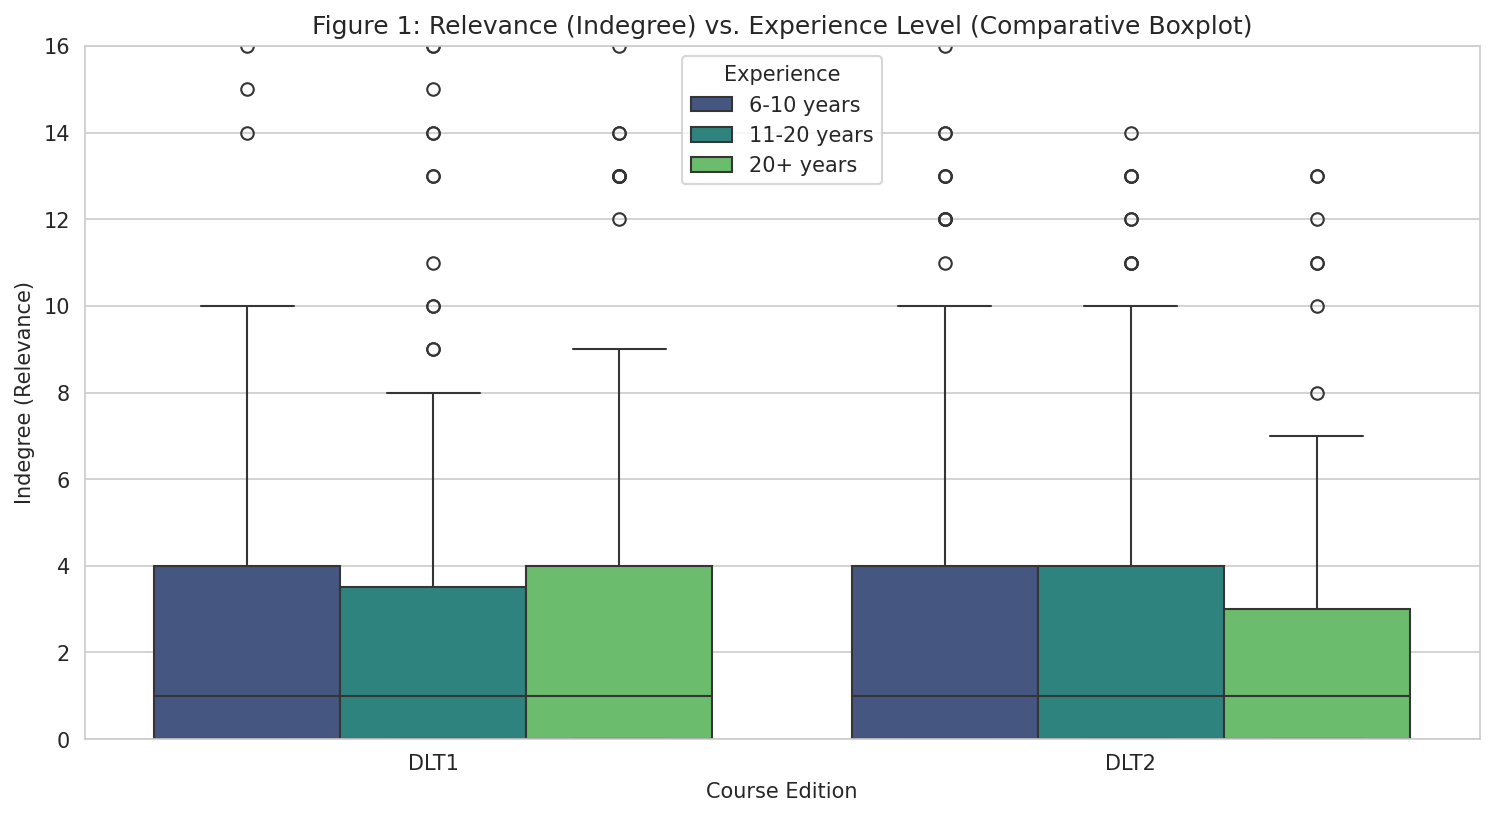

/tmp/ipykernel_845/2888940067.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(data=df_combined, x='role_clean', y='out_degree', hue='Edition', ci=68, palette=['#1f77b4', '#ff7f0e'])


Figure 2 saved as Figure_2_Outdegree_vs_Role_Barplot.png


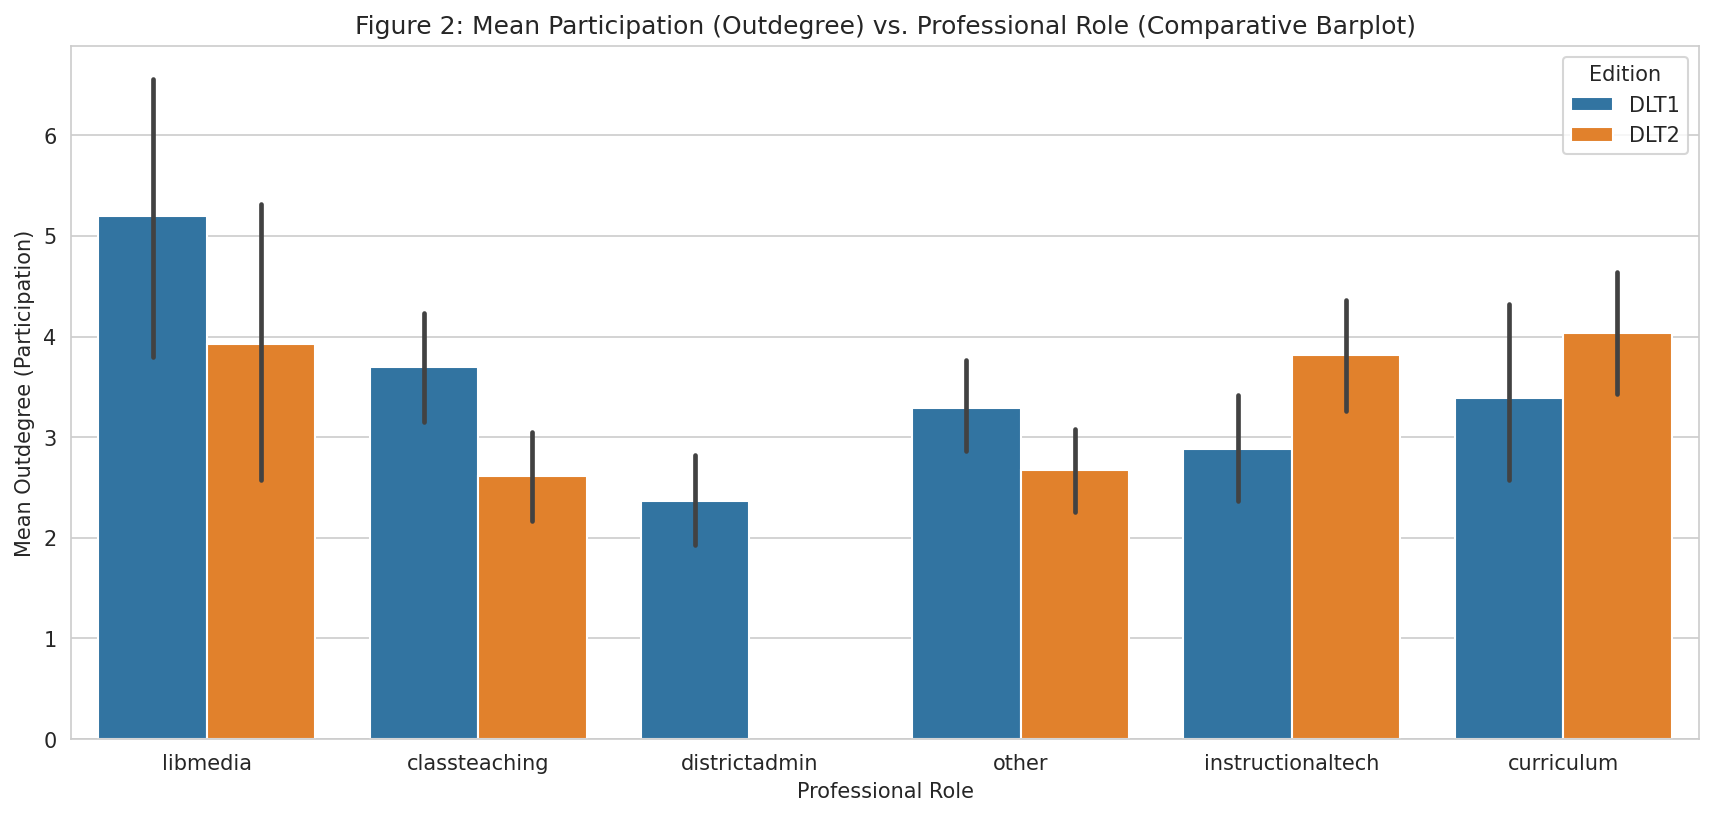

Figure 3 saved as Figure_3_Betweenness_vs_Gender_Violin.png


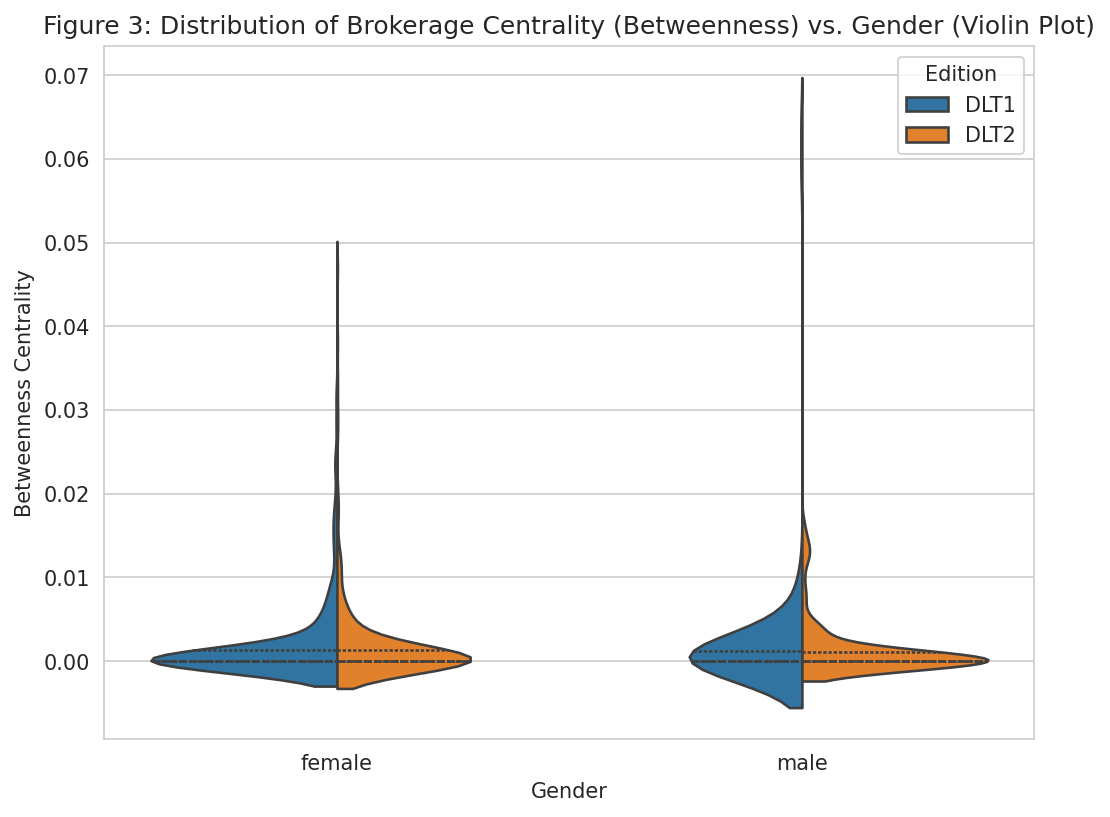

In [23]:
# PHASE 5: Thematic Visualization of Descriptive Results
# Objective: Visually represent centrality trends, especially
# those mean differences observed in Phase 4.1 (Descriptive Statistics).


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# --- Plot 1: Relevance (Indegree) vs. Experience and Edition (Boxplot) ---
plt.figure(figsize=(12, 6))
# Type: Boxplot.
sns.boxplot(data=df_combined, x='Edition', y='in_degree', hue='experience_label',
            hue_order=mappa_esperienza.values(), palette='viridis')
plt.title('Figure 1: Relevance (Indegree) vs. Experience Level (Comparative Boxplot)')
plt.ylabel('Indegree (Relevance)')
plt.xlabel('Course Edition')
plt.legend(title='Experience')
# Limit the Y-axis (vertical) to the 95th percentile to exclude extreme outliers and make the box readable.
plt.ylim(0, df_combined['in_degree'].quantile(0.95) + 1)
save_fig("Indegree_vs_Experience_Boxplot")
plt.show()


# --- Plot 2: Participation (Outdegree) vs. Role and Edition (Barplot) ---
plt.figure(figsize=(14, 6))
# Type: Barplot.
sns.barplot(data=df_combined, x='role_clean', y='out_degree', hue='Edition', ci=68, palette=['#1f77b4', '#ff7f0e'])
plt.title('Figure 2: Mean Participation (Outdegree) vs. Professional Role (Comparative Barplot)')
plt.ylabel('Mean Outdegree (Participation)')
plt.xlabel('Professional Role')
save_fig("Outdegree_vs_Role_Barplot")
plt.show()


# --- Plot 3: Brokerage (Betweenness) vs. Gender and Edition (Violin Plot) ---
plt.figure(figsize=(8, 6))
# Type: Violin Plot.
sns.violinplot(data=df_combined, x='gender', y='betweenness_centrality', hue='Edition', split=True, inner='quartile', palette=['#1f77b4', '#ff7f0e'])
plt.title('Figure 3: Distribution of Brokerage Centrality (Betweenness) vs. Gender (Violin Plot)')
plt.ylabel('Betweenness Centrality')
plt.xlabel('Gender')
save_fig("Betweenness_vs_Gender_Violin")
plt.show()

### Analysis of Plot 1: Relevance (In-Degree) vs. Experience and Edition (Box Plot)

Interpretation of the Box Plot (The Box)
- Median (Line Inside the Box): The horizontal line inside the box indicates the 50th percentile.

Observation: Across all experience categories and in both editions (DLT1 and DLT2), the median is very close to 0 or 1 received interaction.

Conclusion: Half of the participants (50%) receive very few interactions, confirming that the vast majority of users are peripheral actors (passive participants).

- The Box (25th and 75th Percentiles): The box encloses the central 50% of the data.

Observation: The height of the box is compressed in the lower part (near 0-4 interactions).

Conclusion: 75% of the participants receive fewer than 4-5 interactions.

- The Lines and Dots (Asymmetry and Outliers)

Whiskers and Y-Axis Limit: The whiskers (the lines extending from the box) and the plt.ylim(0, ...) setting indicate that the distribution is extremely asymmetrical (skewed).

The Dots (Outliers): The dots above the whiskers (which are excluded by the display limit you set, but exist up to 35 or 58) are the real key actors (Hubs) of the network.

- Conclusion (Link to the RQ)

Plot 1 visually demonstrates the lack of significance (low $R^2$) found in Model 1 (In-Degree). The In-Degree is strongly concentrated towards zero for all experience levels and in both editions. This means that relevance (being consulted) is not distributed based on experience; it is a trait possessed only by a small fraction of users, the super-connected, whose activity is not explained by their professional background.

### Analysis of Plot 2: Participation (Out-Degree) vs. Role and Edition

- Interpretation of the Most Active Roles

libmedia edition DLT1 is the most active role overall (highest average Out-Degree). libmedia stands for Librarian/Media Specialist or Library/Media. These roles, given their nature as resource and information managers, are very active in initiating interactions in DLT1.

classteaching is high in both editions. Classroom teachers are a category naturally active in educational forums.

- Comparison DLT1 vs. DLT2

Your observation is that the blue bar (DLT1) is generally higher than the orange bar (DLT2), by about 1 average point (e.g., 4.5 in DLT1 vs 3.5 in DLT2).

Observation: Participants in DLT1 were, on average, more active in sending interactions compared to participants in DLT2, regardless of their professional role.

Implication for Design (RQ): If there was a difference in course design between the two editions, this difference led to a slight general decrease in participation activity (Out-Degree) in DLT2 compared to DLT1.

- Conclusion (Link to the Regression)

Plot 2 shows a clear descriptive trend (the average Out-Degree is higher in DLT1 for almost all roles), indicating that participants in the first edition were slightly more proactive. However, Model 2 (Regression for Out-Degree) showed that the differences between roles and the interaction $\text{Role} \times \text{Edition}$ are not statistically significant (P-value $ > 0.05$). This means that, although there is a visual reduction in activity in DLT2, this variation cannot be attributed with certainty to the Professional Role. The average activity decreased in general, but the Role is not a robust predictor of why some are more active than others.

### Analysis of Plot 3: Brokerage (Betweenness) vs. Gender and Edition

- Interpretation of the Shape (Violin Plot)

You noticed that the shape is wide at the bottom and pointed at the top.

Meaning: The Violin Plot shows data density. The width at the bottom (near zero) means that the vast majority of participants (men and women, DLT1 and DLT2) have a very low or zero Betweenness Centrality value.

Conclusion: This asymmetrical shape confirms the result of Model 3: brokerage is a very rare trait (75% of participants have a betweenness close to zero), and therefore profile factors struggle to explain it.

- Interpretation of Differences in Width

In Female, the DLT1 part is wider. In Male, the DLT2 part is wider.
If the distribution is wider, it means there are more participants in that range of values. For Betweenness (where the value is very low), this often indicates that in DLT1, women had a broader distribution of "minor brokers" (people with Betweenness slightly above zero).

Contrast with DLT2: If you remember the Top 5 Brokers in DLT2, women occupied all the top 5 brokerage positions.

Implication: The Violin Plot suggests that in DLT2, brokerage power became more concentrated within a few elite women, making the distribution at the bottom slightly narrower.

- Conclusion (Link to the RQ)

The Violin Plot confirms that brokerage is a scarce resource. Visually, we notice a slight consolidation of brokerage in DLT2 (especially among women) (meaning, brokerage became a resource concentrated in fewer hands). Although this female dominance did not turn out to be statistically significant in Model 3, the descriptive analysis and this graph demonstrate that the central intermediary actors shifted by gender between the two editions, while remaining unrelated to Role or Experience.

## 5.2: Comparative Structural Analysis (Plots 4, 5, 6)

Figure 4 saved as Figure_4_DLT2_Outdegree_Histogram.png


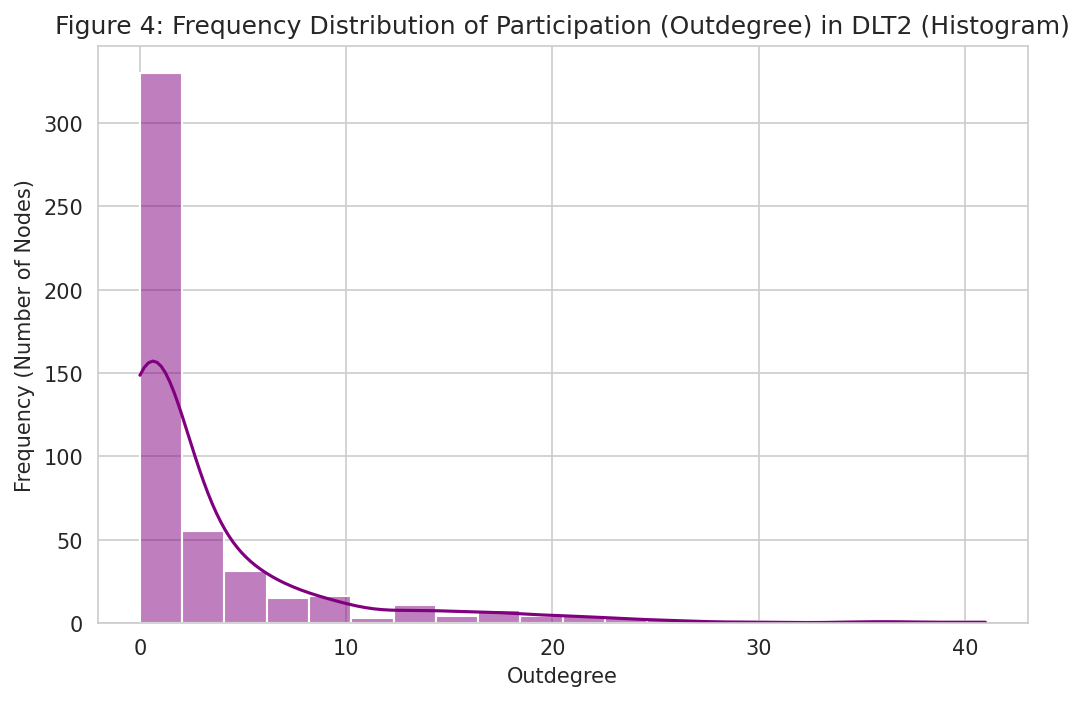

Figure 5 saved as Figure_5_Outdegree_Indegree_Scatter.png


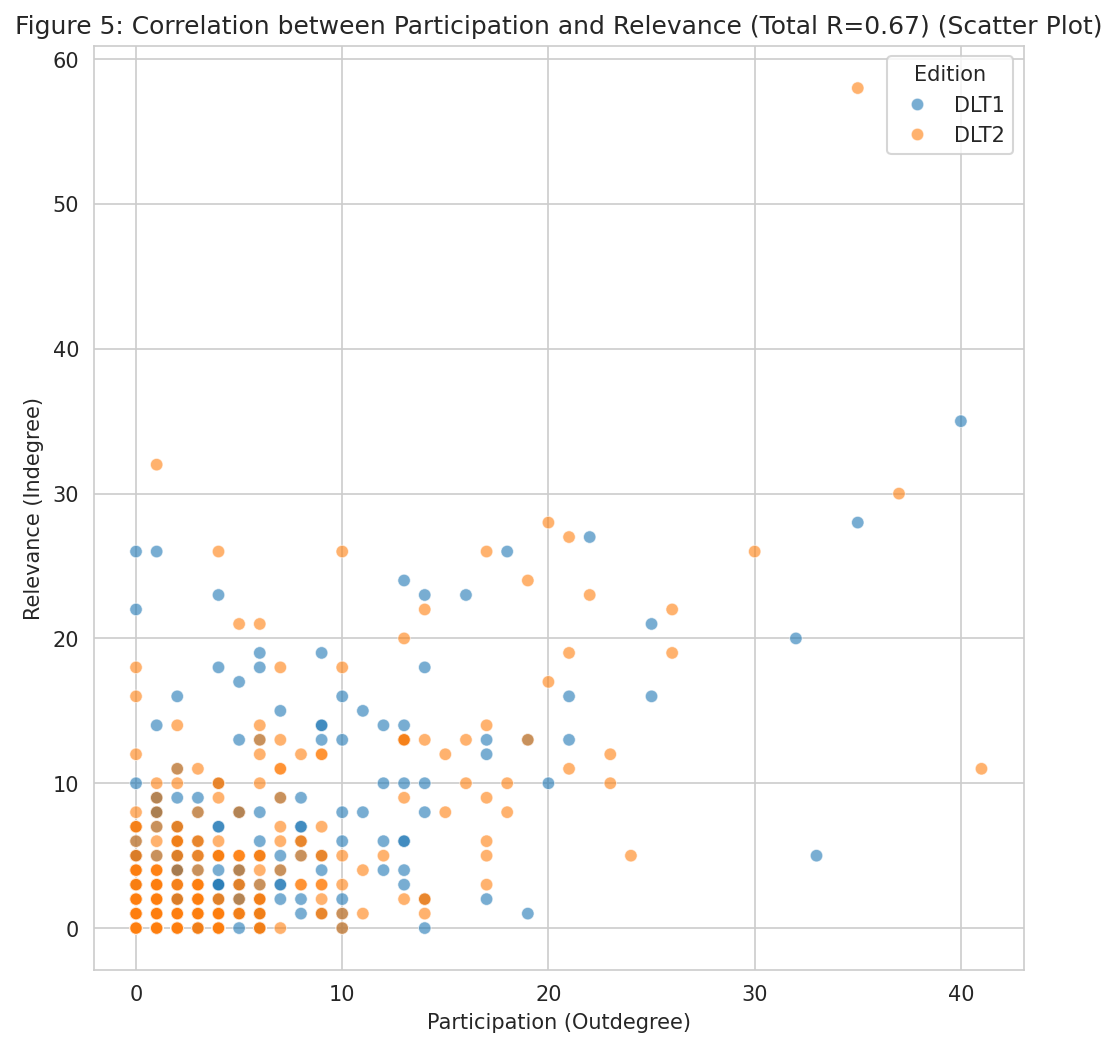

Figure 6 saved as Figure_6_SNA_Indices_Correlation_Heatmap.png


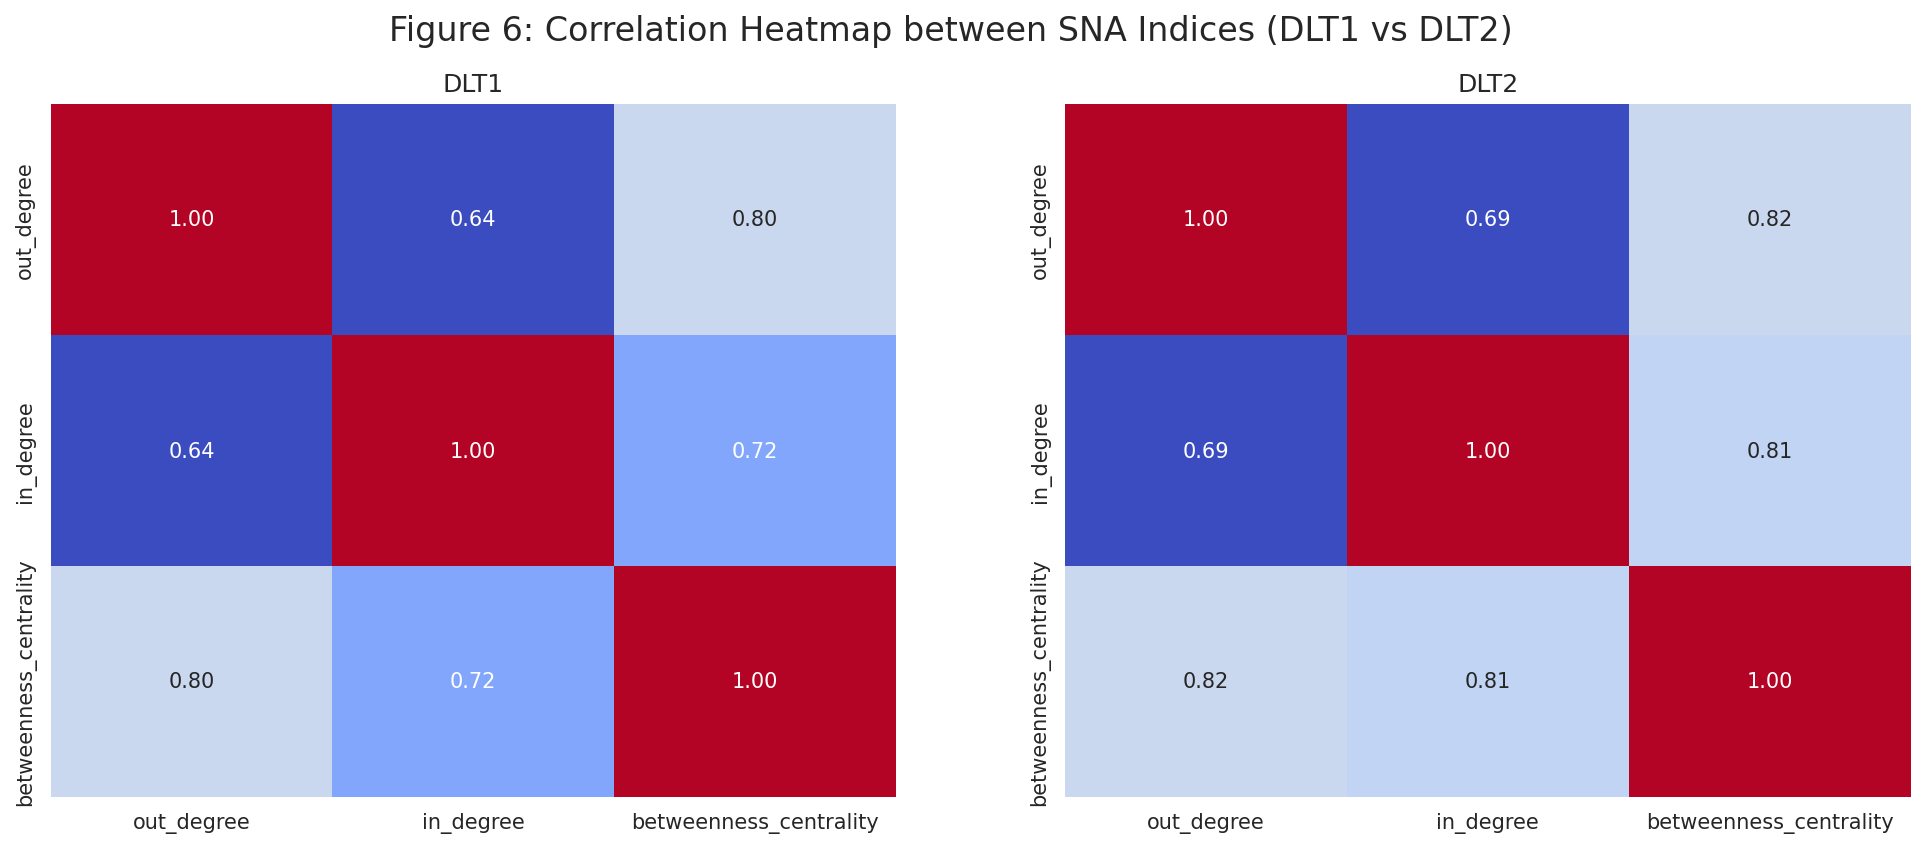

In [24]:
# --- Plot 4: Participation Distribution in DLT2 (Histogram) ---
plt.figure(figsize=(8, 5))
sns.histplot(data=df_analisi_dlt2, x='out_degree', bins=20, kde=True, color='purple')
plt.title('Figure 4: Frequency Distribution of Participation (Outdegree) in DLT2 (Histogram)')
plt.xlabel('Outdegree')
plt.ylabel('Frequency (Number of Nodes)')
save_fig("DLT2_Outdegree_Histogram")
plt.show()


# --- Plot 5: Correlation between Participation and Relevance (Scatter Plot) ---
plt.figure(figsize=(8, 8))
# Calculate the Pearson correlation between In-Degree and Out-Degree.
correlazione_completa = df_combined[['out_degree', 'in_degree']].corr().iloc[0, 1]
# Type: Scatter Plot. Function: Shows the point-by-point relationship between two variables.
sns.scatterplot(data=df_combined, x='out_degree', y='in_degree', hue='Edition', alpha=0.6, palette=['#1f77b4', '#ff7f0e'])
plt.title(f'Figure 5: Correlation between Participation and Relevance (Total R={correlazione_completa:.2f}) (Scatter Plot)')
plt.xlabel('Participation (Outdegree)')
plt.ylabel('Relevance (Indegree)')
save_fig("Outdegree_Indegree_Scatter")
plt.show()


# --- Plot 6: Correlation Heatmap between SNA Indices (New Graph!) ---
correlation_matrix_dlt1 = df_analisi_dlt1[['out_degree', 'in_degree', 'betweenness_centrality']].corr()
correlation_matrix_dlt2 = df_analisi_dlt2[['out_degree', 'in_degree', 'betweenness_centrality']].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 6: Correlation Heatmap between SNA Indices (DLT1 vs DLT2)', fontsize=16)

# DLT1 Heatmap
# Type: Heatmap. Function: Visualizes the correlation matrix between variables.
sns.heatmap(correlation_matrix_dlt1, annot=True, fmt=".2f", cmap='coolwarm', cbar=False, ax=axes[0])
axes[0].set_title('DLT1')

# DLT2 Heatmap
sns.heatmap(correlation_matrix_dlt2, annot=True, fmt=".2f", cmap='coolwarm', cbar=False, ax=axes[1])
axes[1].set_title('DLT2')

save_fig("SNA_Indices_Correlation_Heatmap")
plt.show()

### Analysis of Plot 4: Distribution of Participation (Out-Degree)

- Maximum Frequency (Peak)

Observation: The peak is located at Out-Degree $\approx 0$.

Meaning: This is the most critical data point for the network structure. It indicates that the mode (the most frequent value) of the activity is non-participation.

The majority of participants sent 0 or at most 1 interaction. Terminology: This confirms the existence of a wide periphery of passive or marginal actors.

- The Shape and the Long Tail (Asymmetry)

Observation: The distribution drops immediately and then extends slowly towards the right.

Meaning: This is an extreme positive asymmetry (or right-skewness). It is the visual signature of a network that is not normally distributed (like the bell curve), but follows a Long-Tail Distribution.

SNA Implication: Networks with this shape are defined as Scale-Free or Hierarchical networks. This means that while most nodes have very few connections, a few nodes have a disproportionately high number of connections.

- Conclusion (Link to the Regression)

Plot 4 is the visual proof of the network structure. The distribution of Out-Degree is strongly asymmetrical, with the majority of participants clustered at zero and a long tail towards the right. This lack of variance (almost all data is at zero) is the reason why our profile factors (Gender, Role, Experience) did not turn out to be significant predictors. There is not enough widespread activity to explain. The model can only explain the behavior of the very few actors in the long tail (the Hubs), but these are too few to make the effect significant across the entire sample. The design of the MOOC must address this strong asymmetry if it aims for a more widespread participation.

### Analysis of Plot 5: Correlation between Participation (Out-Degree) and Relevance (In-Degree)

- The Meaning of the Correlation Coefficient ($R=0.67$): Strong-to-Moderate Positive Correlation.

This result is extremely important:
Activity Pays Off: It indicates a strong linear association between sending interactions (Out-Degree) and receiving interactions (In-Degree). In simple terms, those who are more active have a significantly higher probability of being relevant and listened to.

Structural Stability: The value $R=0.67$ is typical for open social networks. It indicates that the fundamental rule of the network, "engagement leads to visibility," is stable across both editions.

- The Two Critical Zones of the Scatter Plot

Clustered Points at the Origin (0,0): The Passive Periphery. The majority of nodes are located at $X \approx 0$ and $Y \approx 0$.

Visually confirms the extreme asymmetry of the network (already seen in the Box Plot and Histogram): most participants are passive.

Dispersion at the Top Right: Moderate Correlation. The relationship is not perfect ($R \neq 1.0$).

There are actors who generate a lot of Out-Degree but are not the most relevant nodes (their points are far from the trend line, to the right) and vice versa. The quantity of interactions is important, but it is not the only factor (which opens the door to factors like content quality).

- Final Conclusion (Contrast with the Regression)

The strong correlation ($R=0.67$) between Out-Degree and In-Degree demonstrates that, while our Regression Models (Phase 3) failed to predict centrality based on user profiles (Gender, Role), the internal structure of the network is predictable. The Implication for Design is clear: centrality is disconnected from user background and is determined by their specific level of engagement in the course. The MOOC-Ed design seems to have created an environment where activity itself is the primary resource for acquiring relevance, regardless of professional role or prior experience.

### Analysis of Plot 6: Correlation Heatmap Between SNA Indices

- Correlation A: Relevance vs. Participation (In-Degree vs. Out-Degree)

In-Out: $0.64$ DLT1 - $0.69$ DLT2 - Marginal Increase of +0.05

Interpretation: The relationship between activity and visibility remained strong in both editions. The marginal increase in DLT2 ($R=0.69$) indicates that activity became a slightly more reliable predictor of relevance in the second edition.

- Correlation B: Relevance vs. Brokerage (In-Degree vs. Betweenness)

In-Betweenness: $0.72$ DLT1 - $0.81$ DLT2 - Significant Increase of +0.09

Interpretation: This is the most significant result! In DLT2, the correlation between being popular (Relevance) and being a broker (Control/Intermediation) increased considerably.

Implication on Power: Brokerage power (Betweenness) is no longer randomly distributed; it has consolidated in the hands of the most popular actors. There was a convergence of the two forms of centrality.

- Correlation C: Participation vs. Brokerage (Out-Degree vs. Betweenness)

Out-Betweenness: $0.80$ DLT1 - $0.82$ DLT2 - Minimal Increase of +0.02

Interpretation: Participation activity (Out-Degree) is already a very strong predictor of brokerage in both editions. The increase is minimal, suggesting that those who are active steadily become brokers across both networks.

 - Final Conclusion (The Consolidation of Power in DLT2)

 The Heatmap analysis (Graph 6) provides the strongest implications regarding design and network dynamics. While profile factors do not matter (Phase 3), the way metrics relate to each other changed in DLT2:

 1. Convergence of Power: The significant increase in the correlation between Relevance (In-Degree) and Brokerage (Betweenness) from $0.72$ to $0.81$ is proof that power in the second edition consolidated. Actors who were simply 'popular' also became actors who 'control' the flow of information.

 2. Implication for Design: The design of the second edition (DLT2), while not being a direct predictor of centrality based on profile, favored a more hierarchical network structure where central nodes accumulated multiple forms of power (popularity and control) compared to the first edition, where these were slightly more distributed.

# PHASE VI: Conclusions and Appendix

## 6.1: Conclusions and Implications

The analysis yielded **three main results** which, although they do not confirm the initial profile-based hypotheses, provide definitive conclusions and important implications for the design of MOOC-Eds:

1 - **The association with profile factors is insignificant**: as observed in the inferential results of Phase 4.2, the linear regression models for In-Degree, Out-Degree, and Betweenness Centrality showed an adjusted R-squared close to 0 and a non-significant Prob(F-statistic) (all P-values were greater than 0.05).

We cannot establish a statistically significant association between pre-existing profile factors (Gender, Role, Experience) and network centrality in these editions. Network dynamics are disconnected from the socio-demographic background of the participants.

2 - **Centrality is determined by engagement**: Plot 5 (Scatter Plot) revealed a strong positive correlation ($R = 0.67$) between Participation (Out-Degree) and Relevance (In-Degree).

In these networks, activity itself is the primary predictor of relevance. The network is highly asymmetrical (as confirmed by the Histogram, Plot 4), meaning that centrality is dominated by a minority of active users.

3 - **The design of DLT2 favored the consolidation of power**: the correlation Heatmap (Plot 6) showed a sharp increase in the link between Relevance (In-Degree) and Betweenness, with $R$ rising from 0.72 in DLT1 to 0.81 in DLT2.

The design of the DLT2 edition, despite not altering the impact of user profiles, led to a more hierarchical network structure. Intermediation power (betweenness) consolidated in the hands of users who were already popular.

**Implications for the Future Design of MOOC-Eds**

- Focus on Unlocking Participation: since most participants are passive and participation is the driver of centrality, design efforts should focus on task instructions that incentivize a wider dispersion of activity.

- Inclusivity vs. Consolidation: given the slight consolidation of power in DLT2, future designs should carefully evaluate whether their goal is to foster the emergence of a few central leaders (consolidation) or to distribute influence more equitably (inclusivity).

- Proposal for Future Research: it would be useful to enrich the regression models with endogenous course variables, such as Content Quality (text analysis, sentiment) or the Timing of Interventions, to identify the true predictors of engagement and centrality.

**Limitations of the Research and Future Directions**

The methodological and analytical limitations of this study should be acknowledged and highlighted:

- Sample Limitations and Statistical Power: the research was based on the comparison of only two editions of the MOOC-Ed (DLT1 and DLT2). This small number of samples limits the statistical power required to detect weak associations (particularly after the regression yielded null results) and reduces the generalizability of the findings.

- Missing Variables (Endogenous Ones): the regression model, based solely on pre-existing (exogenous) profile variables, failed to explain the variance in centrality. The true predictor of centrality is likely linked to behavior within the course, such as the **quality of text content** or the **timing** of interactions.

These limitations offer clear directions for the future: future research should focus on including a larger sample and enriching the model with content variables derived from Natural Language Processing (NLP) techniques.

## 6.2: Appendix: Note on AI Assistance and Methodology

### **Role of Artificial Intelligence in Code Development**

This Notebook is the result of a hybrid process that combined the efficiency of automated code generation with rigorous control and methodological development by the researcher.

**AI Model used**: **Gemini 2.5 Flash** (Google)

**Base Code and Researcher's Initial Contribution**

The initial code for the project structure was generated by the AI. The researcher intervened with fundamental modifications, transforming the template into a valid and complete analysis to ensure the correctness of data processing and compliance with project requirements.

**Prompt used for the initial code:**:

*"Write me a complete code for a scientific analysis.*
*I need to analyze the impact of profile variables (Gender, Role, Experience) on network centrality (In-Degree, Out-Degree, Betweenness) across two different datasets (DLT1 and DLT2).*
*The code must include:*
1. *data loading (separate nodes and edges for DLT1 and DLT2)*
2. *alignment and cleaning phase (e.g., removing duplicates, handling facilitators, etc.)*
3. *construction of two graphs (NetworkX)*
4. *calculation of SNA Centrality indices*
5. *statistical analysis and inferential analysis"*

**Substantial Interventions by the Researcher on the Code**:

- Addition of the EDA Phase: the initial code did not include an explicit Exploratory Data Analysis (EDA) block; Phase 2.2 was added in its entirety.

- Data Validation: added explicit checking and analysis of null values and duplicates across all four datasets (DLT1/DLT2 nodes and DLT1/DLT2 edges), which was essential for data cleaning.

- Specific Descriptive Analysis: added specific analyses on the distribution of Gender and Professional Roles (DLT1 and DLT2 nodes) and Edge properties (DLT1 and DLT2).

- Error-Proof Alignment Function: implemented an alignment function that uses keyword-based search to resolve case sensitivity inconsistencies and the specific typo (reciever instead of receiver) present in the original files.

- Addition of a Sixth Plot: the comparative Correlation Heatmap between SNA indices (DLT1 vs DLT2).

### **Role of AI in Refining and Presentation**

In the subsequent phases, the AI was utilized as a rewriting and refining tool to strictly adhere to academic presentation standards.

The AI provided the following optimizations based on the researcher's requests:

- Code Refining and Comments: review and abbreviation of inline comments to emphasize the methodological justification of each step (e.g., handling the Reciever typo, removing facilitators, using C() and * in the OLS formula, etc.).

- Synthesis of Results: assistance in structuring summaries of complex results, specifically: synthesizing the descriptive output in the SNA Descriptive Analysis phase + synthesizing the Inferential Interpretation phase, ensuring the correct analysis of $R^2$ and $P$-Values.